## Caricamento dati

In [3]:
import os 
import cv2
import pathlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
#dataset_dir = '/kaggle/input/FIVES-duplicates'
dataset_dir = '../FIVES'
train_dir = pathlib.Path(dataset_dir) / 'train/Original'
test_dir = pathlib.Path(dataset_dir) / 'test/Original'

Iperparametri

In [5]:
seed = 42
epochs = 500
batch_size = 32
img_size = (2048, 2048)
img_shrinked = (512,512)

In [6]:
def create_dataframe(data_dir):
    filepaths = []
    labels = []
    
    for filename in os.listdir(data_dir):
        if filename.endswith('.png'):
            filepath = os.path.join(data_dir, filename)
            
            # Extract class from filename (format: "121_G.png")
            # Assuming the class is the character after the underscore
            class_name = filename.split('_')[1].split('.')[0]  # Gets 'G' from '121_G.png'
            
            filepaths.append(filepath)
            labels.append(class_name)
    
    return pd.DataFrame({'filepath': filepaths, 'class': labels})

path_n_classes_df = create_dataframe(train_dir)

In [7]:
path_n_classes_df.head()

,filepath,class
0,../FIVES/train/Original/287_D.png,D
1,../FIVES/train/Original/600_N.png,N
2,../FIVES/train/Original/71_A.png,A
3,../FIVES/train/Original/186_D.png,D
4,../FIVES/train/Original/34_A.png,A


In [8]:
def mask_character(img):
    img[:60, :60] = 0

'''
    # Normalize to uint8 for OpenCV
    orig_dtype = img.dtype
    if orig_dtype != np.uint8:
        if img.max() <= 1.0:
            img_u8 = (img * 255).astype(np.uint8)
        else:
            img_u8 = img.astype(np.uint8)
    else:
        img_u8 = img

    # Ensure 3 channels
    if img_u8.ndim == 2:
        img_u8 = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB)

    # RGB -> BGR -> LAB
    bgr = cv2.cvtColor(img_u8, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to L channel (uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # Merge and convert back to RGB
    lab = cv2.merge((l, a, b))
    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Return in the same value range expected by caller
    if orig_dtype == np.uint8:

        return rgb
    else:

        return rgb.astype(np.float32)'''

'\n    # Normalize to uint8 for OpenCV\n    orig_dtype = img.dtype\n    if orig_dtype != np.uint8:\n        if img.max() <= 1.0:\n            img_u8 = (img * 255).astype(np.uint8)\n        else:\n            img_u8 = img.astype(np.uint8)\n    else:\n        img_u8 = img\n\n    # Ensure 3 channels\n    if img_u8.ndim == 2:\n        img_u8 = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB)\n\n    # RGB -> BGR -> LAB\n    bgr = cv2.cvtColor(img_u8, cv2.COLOR_RGB2BGR)\n    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)\n    l, a, b = cv2.split(lab)\n\n    # Apply CLAHE to L channel (uint8)\n    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))\n    l = clahe.apply(l)\n\n    # Merge and convert back to RGB\n    lab = cv2.merge((l, a, b))\n    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)\n    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)\n\n    # Return in the same value range expected by caller\n    if orig_dtype == np.uint8:\n\n        return rgb\n    else:\n\n        return rgb.astype(np.float32

In [9]:
train_df, val_df = train_test_split(
    path_n_classes_df, 
    test_size=0.2, 
    stratify=path_n_classes_df['class'],
    random_state=42
)

# Create data generators
datagen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    #rescale=1./255,
    rotation_range=30,
    horizontal_flip=False,
    preprocessing_function=mask_character,
)


datagen_val = tf.keras.preprocessing.image.ImageDataGenerator(
    #rescale=1./255,
    preprocessing_function=mask_character
)


train_generator = datagen_train.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='class',
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
)

validation_generator = datagen_val.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='class',
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)

Found 480 validated image filenames belonging to 4 classes.
Found 120 validated image filenames belonging to 4 classes.


/Users/francescospecchia/Desktop/UNI/DL/.venv/lib/python3.12/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


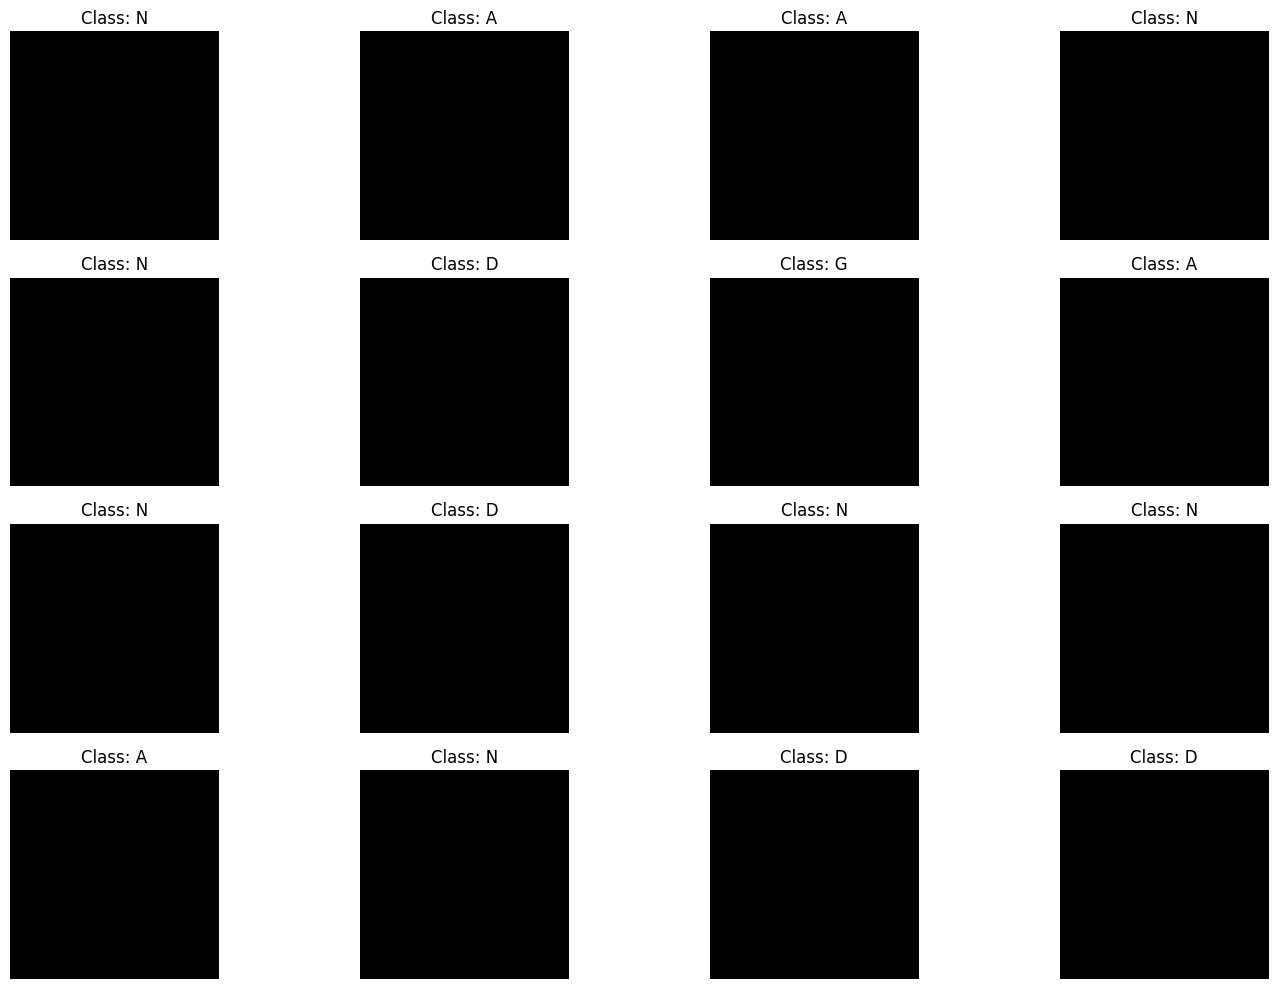

In [10]:
# Prendi un batch
images, labels = next(train_generator)

# Configura la visualizzazione
plt.figure(figsize=(15, 10))

# Ottieni i nomi delle classi
class_names = list(train_generator.class_indices.keys())

# Mostra fino a 16 immagini (o quante ne hai nel batch)
num_images = min(16, len(images))

for i in range(num_images):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i] / 255)
    
    # Trova la classe (per one-hot encoded labels)
    class_idx = np.argmax(labels[i])
    class_name = class_names[class_idx]
    
    plt.title(f"Class: {class_name}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Model Loading

In [11]:
# Monitor F1 score
from sklearn.metrics import f1_score
class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, x_val, y_val, average="macro"):
        super().__init__()
        self.x_val = x_val
        self.y_val = np.argmax(y_val, axis=1)  
        self.average = average
        self.val_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.x_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        f1 = f1_score(
            self.y_val,
            y_pred,
            average=self.average
        )

        self.val_f1.append(f1)
        print(f" - val_f1: {f1:.4f}")

        if logs is not None:
            logs["val_f1"] = f1

In questa sezione carico la ResNet e la compilo 

In [12]:
img_shape = img_shrinked + (3, )
img_shape

(512, 512, 3)

In [13]:
resnet = tf.keras.applications.ResNet50(
    input_shape = img_shape,
    include_top = False,
    weights = 'imagenet'
)

resnet.trainable = True

resnet.summary()

2026-06-22 16:50:38.887351: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-22 16:50:38.887457: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-22 16:50:38.887470: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-22 16:50:38.887483: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-22 16:50:38.887494: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 518, 518,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 128, 128,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 128, 128,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 128, 128,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 128, 128,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 128, 128,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [14]:
def create_model(inputs):
    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = resnet(x, training = False) 
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.activations.gelu(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

model = create_model( tf.keras.Input(shape=img_shape) )

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-3),
    loss = tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 512, 512)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512, 512)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 512, 512)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 512, 512,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 16, 16,    │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu (Gelu)         │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ gelu[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 23,797,380 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [16]:
# Extract validation data from generator to use with F1Callback
x_val = []
y_val = []

validation_generator.reset()
for i in range(len(validation_generator)):
    images, labels = validation_generator[i]
    x_val.append(images)
    y_val.append(labels)

x_val = np.concatenate(x_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

print(f"Validation data shape: {x_val.shape}")
print(f"Validation labels shape: {y_val.shape}")

Validation data shape: (120, 512, 512, 3)
Validation labels shape: (120, 4)


Definizione delle callbacks

In [17]:
# Calculate f1 on validation set at the end of each epoch
f1_callback = F1Callback(x_val, y_val, average="macro")

# Early stopping on validation f1
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_f1', 
    patience=15,  
    mode='max', 
    restore_best_weights=True,
    start_from_epoch=15
)

# Scheduler
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_f1',
    mode='max',
    patience=8,
    factor=0.5,
    min_lr=1e-7,
    start_from_epoch=20
)

In [18]:
images, labels = next(train_generator)

print(f"Images shape: {images.shape}")    # (batch_size, height, width, channels)
print(f"Labels shape: {labels.shape}")    # (batch_size, num_classes)
print(f"First label shape: {labels[0].shape}")

Images shape: (32, 512, 512, 3)
Labels shape: (32, 4)
First label shape: (4,)


In [19]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[f1_callback, early_stopping, reduce_lr]
)

Epoch 1/500


2026-06-22 16:51:09.710569: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 6/15 ━━━━━━━━━━━━━━━━━━━━ 1:53 13s/step - accuracy: 0.1630 - loss: 1.5636

KeyboardInterrupt: 

## Loss and accuracy plotting

In [ ]:
plt.figure(figsize = (10,7))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy') 
plt.plot(f1_callback.val_f1, label="validation f1")


plt.legend()  
plt.ylim([0,1]) 
#plt.xticks(range(0,n_epochs))
plt.yticks(np.array(range(10))/10)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Batch size: {batch_size}')
plt.grid('both', linestyle='--')
plt.tight_layout()
plt.savefig(f'accuracy_bs{batch_size}.pdf')

NameError: name 'history' is not defined

<Figure size 1000x700 with 0 Axes>

In [ ]:
plt.figure(figsize = (10,7))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='validation loss') 

plt.legend()  
#plt.xticks(range(0,n_epochs))
plt.semilogy()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Batch size: {batch_size}')
plt.grid('both', linestyle='--')
plt.tight_layout()
plt.savefig(f'loss_bs{batch_size}.pdf')

## Test set

In [20]:
test_df = create_dataframe(test_dir)
test_df

,filepath,class
0,../FIVES/test/Original/118_G.png,G
1,../FIVES/test/Original/168_N.png,N
2,../FIVES/test/Original/34_A.png,A
3,../FIVES/test/Original/195_N.png,N
4,../FIVES/test/Original/91_D.png,D
...,...,...
195,../FIVES/test/Original/114_G.png,G
196,../FIVES/test/Original/164_N.png,N
197,../FIVES/test/Original/60_D.png,D
198,../FIVES/test/Original/199_N.png,N


In [21]:
datagen_test = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = mask_character
)

test_generator = datagen_test.flow_from_dataframe(
    test_df,
    x_col= 'filepath',
    y_col = 'class',
    target_size = img_shrinked,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 200 validated image filenames belonging to 4 classes.


In [22]:
test_pred = model.predict(test_generator)
print(test_pred.shape)
pred_labels = np.argmax(test_pred, axis = 1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step
(200, 4)


[2, 3, 0, 3, 1, 1, 3, 2, 3, 2, 2, 1, 1, 0, 0, 1, 3, 2, 2, 3, 2, 1, 1, 0, 3, 3, 2, 1, 1, 0, 3, 0, 0, 1, 3, 2, 2, 0, 3, 3, 2, 2, 1, 2, 0, 0, 3, 1, 1, 1, 3, 2, 0, 1, 2, 3, 2, 0, 1, 0, 3, 2, 3, 1, 1, 2, 3, 3, 2, 0, 3, 1, 0, 3, 2, 1, 1, 2, 0, 0, 0, 3, 2, 3, 2, 1, 1, 2, 0, 0, 3, 1, 1, 1, 0, 3, 2, 3, 1, 1, 2, 3, 2, 0, 0, 2, 0, 1, 3, 0, 0, 1, 3, 2, 1, 3, 2, 1, 1, 0, 3, 0, 1, 2, 3, 2, 0, 0, 1, 2, 3, 0, 1, 0, 2, 3, 2, 2, 1, 3, 0, 0, 2, 3, 0, 1, 3, 2, 0, 2, 1, 3, 0, 1, 0, 1, 2, 3, 1, 0, 2, 0, 3, 3, 0, 1, 3, 2, 1, 3, 0, 0, 2, 1, 2, 3, 0, 1, 2, 3, 0, 1, 3, 0, 2, 2, 0, 1, 2, 3, 0, 1, 0, 3, 2, 2, 3, 1, 3, 0]
Test Accuracy: 0.2500


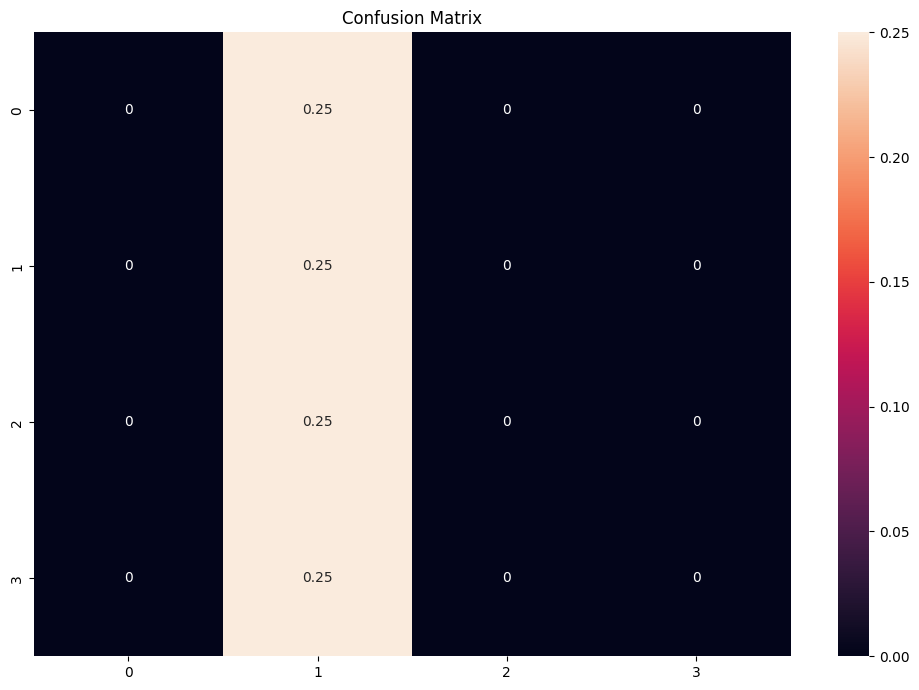

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sn

# true labels
true_labels = test_generator.classes
classes = np.unique(true_labels)

print(true_labels)
# accuracy
acc = accuracy_score(true_labels, pred_labels)

print(f"Test Accuracy: {acc:.4f}")

cm = confusion_matrix(true_labels, pred_labels, normalize='pred')
df_cm = pd.DataFrame(cm, index = [i for i in classes],
                  columns = [i for i in classes])
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True)
plt.title("Confusion Matrix")
plt.tight_layout()

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 512, 512)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512, 512)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 512, 512)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 512, 512,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 16, 16,    │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu (Gelu)         │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ gelu[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 71,445,262 (272.54 MB)

 Trainable params: 23,797,380 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 47,594,762 (181.56 MB)

In [30]:
model.layers[-5:]

[<Functional name=resnet50, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

TypeError: unsupported operand type(s) for /: 'NoneType' and 'float'

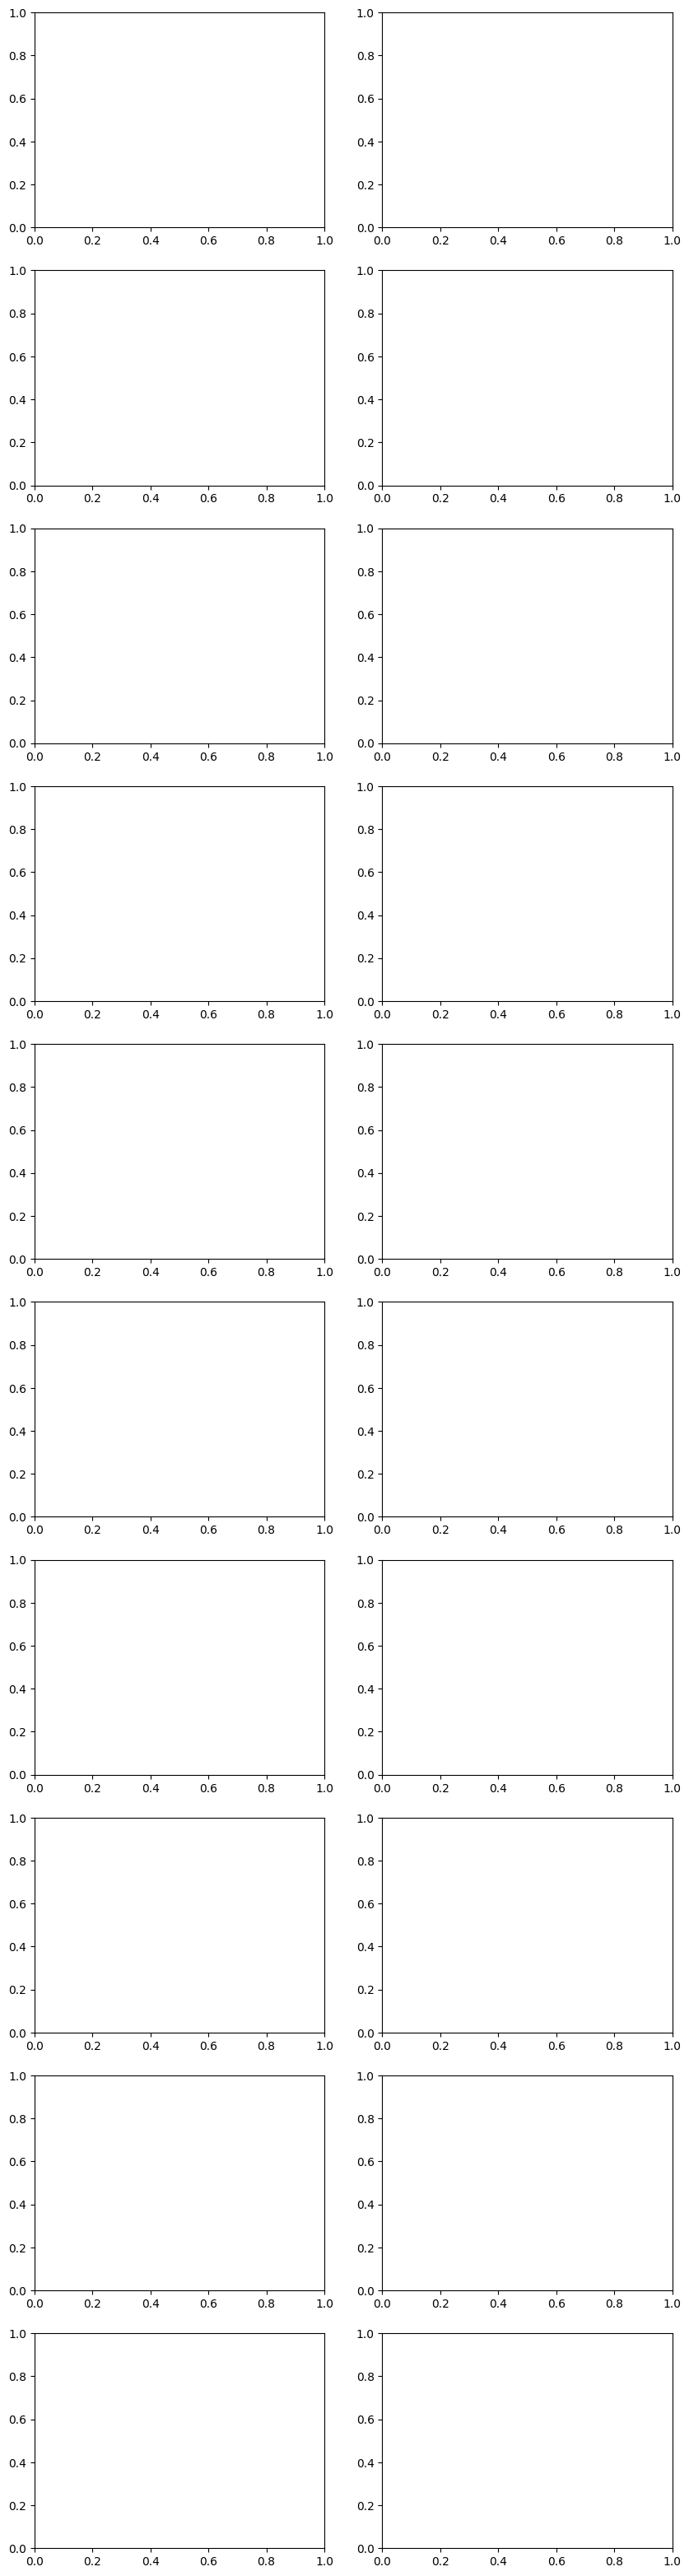

In [ ]:
class_labels = ['A', 'D', 'G', 'N']

grad_inputs = tf.keras.Input(shape=img_shape)
feature_maps = model.layers[-5](grad_inputs)
x = model.layers[-4](feature_maps)
x = model.layers[-3](x)
x = model.layers[-2](x)
grad_predictions = model.layers[-1](x)

grad_model = tf.keras.Model(
    inputs=grad_inputs,
    outputs=[feature_maps, grad_predictions]
)

def make_gradcam_heatmap(img_array, grad_model, pred_index=None):
    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        pred_index = int(pred_index)
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, feature_maps)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    feature_maps = feature_maps[0]

    heatmap = tf.reduce_sum(feature_maps * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
    return heatmap.numpy()

def load_image_for_gradcam(filepath):
    image = tf.keras.utils.load_img(filepath, target_size=img_shrinked)
    image_array = tf.keras.utils.img_to_array(image)
    image_array = mask_character(image_array)
    image_array = image_array / 255.0
    return image_array

def get_eval_dataframe(split='test'):
    if split == 'test':
        return test_df
    if split == 'train':
        return create_dataframe(train_dir)
    raise ValueError("split must be either 'test' or 'train'")

def plot_random_gradcams(split='test', n_samples=6, seed=42):
    eval_df = get_eval_dataframe(split)
    rng = np.random.default_rng(seed)
    n_samples = min(n_samples, len(eval_df))
    sample_indices = rng.choice(len(eval_df), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(sample_indices):
        filepath = eval_df.iloc[idx]['filepath']
        true_label = eval_df.iloc[idx]['class']

        image_array = load_image_for_gradcam(filepath)
        batch = np.expand_dims(image_array, axis=0)

        predictions = model.predict(batch, verbose=0)[0]
        pred_index = int(np.argmax(predictions))
        heatmap = make_gradcam_heatmap(batch, grad_model, pred_index=pred_index)

        axes[row, 0].imshow(image_array)
        axes[row, 0].set_title(f'{split.title()} true: {true_label}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(image_array)
        axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.45)
        axes[row, 1].set_title(
            f'{split.title()} pred: {class_labels[pred_index]} ({predictions[pred_index]:.2f})'
        )
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

plot_random_gradcams(split='test', n_samples=10, seed=14)
# To visualize training samples instead, run:
plot_random_gradcams(split='train', n_samples=10, seed=seed)

In [ ]:
model.save(f'resnet_{acc:.4f}.keras')